## Law Gender Bias - 2 OBJECTIVES

### Multi Task Learning

* **Dataset:** Law Gender Bias
* **Task :** Classification
* **Target 1:** Bias - general
* **Target 2:** Bias with a target
* **Target 3:** Bias with a target

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import random
import numpy as np

import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer
from typing import Any
from collections.abc import Callable
from sklearn.model_selection import train_test_split

/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes
from machinemoo.analysis.metrics import compute_hypervolume_progress

from scalarization import NLPScalarization

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


In [4]:
# Setting a seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

## Dataset and Model

In [5]:
def prepare_datasets(json_path: str): 

    with open(json_path, 'r') as f:
        data = json.load(f)

    train_keys, test_keys = train_test_split(list(data.keys()), test_size=0.1, random_state=42)
    train_keys, val_keys = train_test_split(train_keys, test_size=0.2, random_state=42)

    train_data = {key: data[key] for key in train_keys}
    val_data= {key: data[key] for key in val_keys}
    test_data = {key: data[key] for key in test_keys}
    
    return train_data, val_data, test_data 

In [6]:
#train_data, val_data, test_data = prepare_datasets('../ap/files/annotate_filled.json')
train_data, val_data, test_data = prepare_datasets('../lesao/files/annotate_filled.json')   

In [7]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [8]:
# Cell 3: Dataset class
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"
MAX_LEN = 512
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, cache_dir="transformers")

class MultiTaskDataset(Dataset):
    """
    Flexible dataset for multi-task classification from a JSON-like dict format.
    Supports multiple text chunks and multiple label fields.
    """

    def __init__(self,
                 data: dict,
                 tokenizer,
                 max_length: int = 128,
                 chunk_field: str = "vies_contexto",
                 label_extractors: dict[str, Callable[[dict[str, Any]], int]] = {},
                ) -> None:
        """
        Parameters:
        - data: loaded JSON-like dict
        - tokenizer: HuggingFace tokenizer
        - max_length: max token length
        - chunk_field: which text chunk to use (e.g., 'vies_contexto')
        - label_extractors: dictionary mapping task names to label extraction functions
        - data_type: optional, used for augmentation
        """
        self.tokenizer = tokenizer
        self.max_length = max_length

        self.texts = []
        self.labels = {task: [] for task in label_extractors}

        for item in data.values():
            for text in item.get(chunk_field, []):
                self.texts.append(text)
                for task_name, extractor_fn in label_extractors.items():
                    label = extractor_fn(item)
                    self.labels[task_name].append(label)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        encoding = self.tokenizer.encode_plus(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            add_special_tokens=True
        )

        item = {
            'input_ids': torch.LongTensor(encoding['input_ids']),
            'attention_mask': torch.LongTensor(encoding['attention_mask'])
        }

        for task_name in self.labels:
            item[f'{task_name}'] = torch.tensor(self.labels[task_name][idx], dtype=torch.long)

        return item

In [22]:
def key_presence_extractor(key: str, subkey: str = "") -> Callable[[dict[str, Any]], int]:
    """
    Returns a function that checks if `key` (and optionally `subkey`) is present in the sample.
    Useful for binary presence labels.
    """
    def extractor(sample: dict[str, Any]) -> int:
        if subkey != "":
            result = subkey in sample.get(key, {})
        else:
            val = sample.get(key, [""])[0] if isinstance(sample.get(key), list) else sample.get(key)
            result = bool(val)
        return int(result)
    return extractor

In [10]:
label_extractors = {
    "bias": key_presence_extractor("vies"),
    "bias_woman": key_presence_extractor("vies_alvo", subkey="mul"),
    "bias_defendant": key_presence_extractor("vies_alvo", subkey="reu")
}

In [11]:
trainset = MultiTaskDataset(data=train_data, tokenizer=tokenizer, label_extractors=label_extractors)
train_dataloader = DataLoader(trainset, batch_size=64, shuffle=True)

valset = MultiTaskDataset(data=val_data, tokenizer=tokenizer, label_extractors=label_extractors)
valid_dataloader = DataLoader(valset, batch_size=64)

testset = MultiTaskDataset(data=test_data, tokenizer=tokenizer, label_extractors=label_extractors)
test_dataloader = DataLoader(testset, batch_size=8)


In [12]:
model_name = "neuralmind/bert-base-portuguese-cased"

## MOO Modeling and Training

* MOO methods:
    * MOLA
    * Random Weights

In [13]:
opt_params = {
    'node_time_limit': 2,
    'target_size': 150,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}
task_names = list(label_extractors.keys())

16:18:06 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
16:18:06 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/2 - Training:   0%|          | 0/5 [00:00<?, ?it/s]/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/torch/utils/checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
Evaluating: 100%|██████████| 5/5 [00:03<00:00,  1.41it/s]
16:18:14 | DEBUG | machinemoo | Finding 2th individual minimum
Evaluating: 100%|██████████| 5/5 [00:03<00:00,  1.37it/s]
16:18:25 | DEBUG | machinemoo | Finding 3th individual minimum
Evaluating: 100%|██████████| 5/5 [00:03<00:00,  1.34it/s]
16:18:36 | DEBUG | machinemoo | Calculated weights: [0.93156193 0.         0.06843807]
16:18:36 | DEBUG | machinemoo | Importance: 0.001296825561877657
16:18:36 | DEBUG | machinemoo | Global lower bound (y*): [0.7168

new solution added [0.70897496 0.28825156 0.86881784]
solution dominated [0.7181779  0.30744535 0.94618498]
solution dominated [0.71684165 0.28920866 0.93971009]



16:18:48 | DEBUG | machinemoo | Calculated weights: [0.         0.98793226 0.01206764]
16:18:48 | DEBUG | machinemoo | Importance: 0.00041825559015915177
16:18:48 | DEBUG | machinemoo | Global lower bound (y*): [0.70897496 0.28782822 0.86881784]
16:18:48 | DEBUG | machinemoo | Iteration 2
16:18:48 | DEBUG | machinemoo | Solutions list: [array([0.70897496, 0.28825156, 0.86881784]), array([0.71950319, 0.28782822, 0.9034819 ])]
Evaluating: 100%|██████████| 5/5 [00:03<00:00,  1.31it/s]

new solution added [0.70755131 0.27115233 0.84054589]
solution dominated [0.70897496 0.28825156 0.86881784]
solution dominated [0.71950319 0.28782822 0.9034819 ]



16:18:59 | DEBUG | machinemoo | Calculated weights: [0.33320024 0.33364487 0.33315489]
16:18:59 | DEBUG | machinemoo | Importance: -1.6503352573415953e-09
16:18:59 | DEBUG | machinemoo | Global lower bound (y*): [0.70755131 0.27115233 0.84054589]
16:18:59 | DEBUG | machinemoo | Iteration 3
16:18:59 | DEBUG | machinemoo | Solutions list: [array([0.70755131, 0.27115233, 0.84054589])]
Evaluating: 100%|██████████| 5/5 [00:03<00:00,  1.30it/s]

...


16:57:37 | DEBUG | machinemoo | Calculated weights: [5.28596667e-01 1.42169702e-06 4.71401912e-01]
16:57:37 | DEBUG | machinemoo | Importance: 0.0011319261536936642
16:57:37 | DEBUG | machinemoo | Global lower bound (y*): [0.4635704  0.00092162 0.29263557]
16:57:37 | DEBUG | machinemoo | Iteration 148
16:57:37 | DEBUG | machinemoo | Solutions list: [array([0.46994115, 0.00092162, 0.29263557]), array([0.4635704 , 0.00092843, 0.29977925]), array([0.46922475, 0.00095887, 0.29762766])]
Evaluating: 100%|██████████| 5/5 [00:05<00:00,  1.18s/it]

new solution dominated [0.47051226 0.00092353 0.29462606]



16:57:55 | DEBUG | machinemoo | Calculated weights: [5.28596667e-01 1.42169702e-06 4.71401912e-01]
16:57:55 | DEBUG | machinemoo | Importance: 0.0011319261536936642
16:57:55 | DEBUG | machinemoo | Global lower bound (y*): [0.4635704  0.00092162 0.29263557]
16:57:55 | DEBUG | machinemoo | Iteration 149
16:57:55 | DEBUG | machinemoo | Solutions list: [array([0.46994115, 0.00092162, 0.29263557]), array([0.4635704 , 0.00092843, 0.29977925]), array([0.46922475, 0.00095887, 0.29762766])]
Evaluating: 100%|██████████| 5/5 [00:05<00:00,  1.18s/it]

new solution dominated [0.47081304 0.00094392 0.29908198]



16:58:13 | DEBUG | machinemoo | Calculated weights: [5.28596667e-01 1.42169702e-06 4.71401912e-01]
16:58:13 | DEBUG | machinemoo | Importance: 0.0011319261536936642
16:58:13 | DEBUG | machinemoo | Global lower bound (y*): [0.4635704  0.00092162 0.29263557]
16:58:13 | DEBUG | machinemoo | Iteration 150
16:58:13 | DEBUG | machinemoo | Solutions list: [array([0.46994115, 0.00092162, 0.29263557]), array([0.4635704 , 0.00092843, 0.29977925]), array([0.46922475, 0.00095887, 0.29762766])]


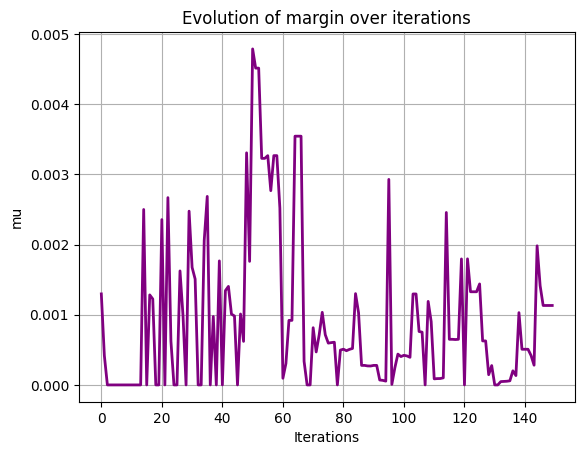

16:58:13 | INFO | machinemoo | Fit runtime: 2407.62 seconds


In [14]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names,
                            model_name = model_name,
                            gradient = False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

In [15]:
objs

array([[0.46994115, 0.00092162, 0.29263557],
       [0.4635704 , 0.00092843, 0.29977925],
       [0.46922475, 0.00095887, 0.29762766]])

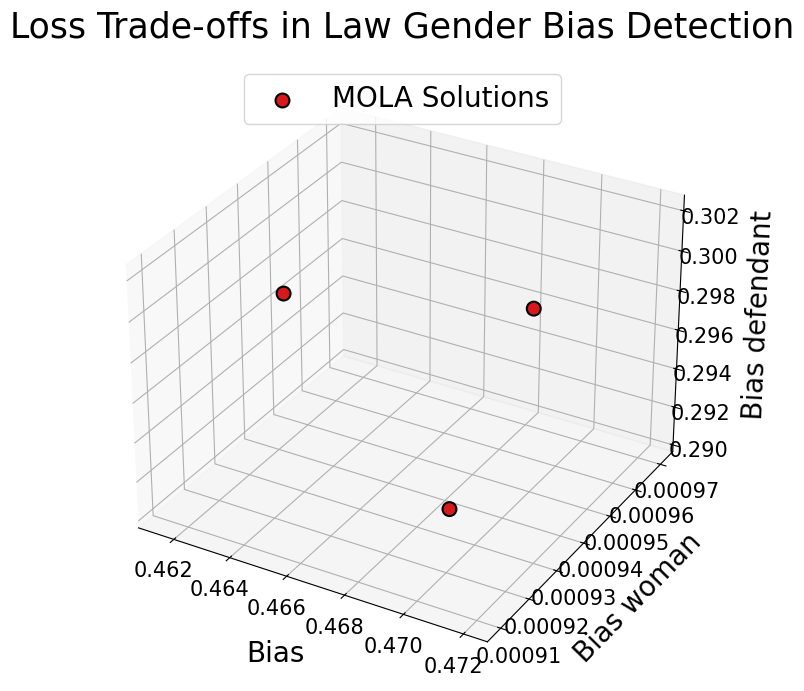

In [16]:
title="Loss Trade-offs in Law Gender Bias Detection"
plot_pareto(methods={'mola': objs},
            labels=task_names, 
            title=title,
            fontsize=20,
            figsize=(10,7),
            save_path='images/3_objs_mola.pdf'
            )

16:58:20 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
16:58:20 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/2 - Training:   0%|          | 0/5 [00:00<?, ?it/s]/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/torch/utils/checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
Evaluating: 100%|██████████| 5/5 [00:05<00:00,  1.17s/it]
16:58:39 | DEBUG | machinemoo | Finding 2th individual minimum
Evaluating: 100%|██████████| 5/5 [00:05<00:00,  1.16s/it]
16:58:58 | DEBUG | machinemoo | Finding 3th individual minimum
Evaluating: 100%|██████████| 5/5 [00:05<00:00,  1.18s/it]
16:59:17 | INFO | machinemoo | [Lipschitz] Updated global lower bounds: [ -11.00811841 -109.40718549  -34.80088942]
16:59:17 | DEBUG | machinemoo | Calculated weights: [0. 1. 0.]
16:59:17 | DEBUG | machinemoo | Impor

new solution added [0.68746357 0.66477244 0.5950617 ]
solution dominated [0.69000251 0.73904711 0.61553438]
solution dominated [0.68757682 0.70356268 0.60080606]


16:59:36 | DEBUG | machinemoo | Calculated weights: [0. 1. 0.]
16:59:36 | DEBUG | machinemoo | Importance: 101.72568030357361
16:59:36 | DEBUG | machinemoo | Global lower bound (y*): [ -11.00811841 -101.06090786  -47.70597514]
16:59:36 | DEBUG | machinemoo | Iteration 2
16:59:36 | DEBUG | machinemoo | Solutions list: [array([0.68746357, 0.66477244, 0.5950617 ]), array([0.68532488, 0.70132205, 0.62058976])]
Evaluating: 100%|██████████| 5/5 [00:05<00:00,  1.18s/it]
16:59:55 | INFO | machinemoo | [Lipschitz] Updated global lower bounds: [ -12.77446071 -101.06090786  -47.70597514]


new solution added [0.68950375 0.62820873 0.60195847]


16:59:55 | DEBUG | machinemoo | Calculated weights: [0. 1. 0.]
16:59:55 | DEBUG | machinemoo | Importance: 101.6891165971756
16:59:55 | DEBUG | machinemoo | Global lower bound (y*): [ -12.77446071 -101.06090786  -47.70597514]
16:59:55 | DEBUG | machinemoo | Iteration 3
16:59:55 | DEBUG | machinemoo | Solutions list: [array([0.68950375, 0.62820873, 0.60195847]), array([0.68746357, 0.66477244, 0.5950617 ]), array([0.68532488, 0.70132205, 0.62058976])]
Evaluating: 100%|██████████| 5/5 [00:05<00:00,  1.17s/it]
17:00:14 | INFO | machinemoo | [Lipschitz] Updated global lower bounds: [ -24.89953099 -101.06090786  -47.70597514]


...

17:46:01 | DEBUG | machinemoo | Calculated weights: [0. 0. 1.]
17:46:01 | DEBUG | machinemoo | Importance: 31.39111343920231
17:46:01 | DEBUG | machinemoo | Global lower bound (y*): [-21.90358024 -19.40182781 -31.07806737]
17:46:01 | DEBUG | machinemoo | Iteration 148
17:46:01 | DEBUG | machinemoo | Solutions list: [array([0.6874073 , 0.04367834, 0.32148321]), array([0.68668504, 0.04412341, 0.3174469 ]), array([0.68862138, 0.04376684, 0.31983668]), array([0.68760079, 0.04386467, 0.31699912]), array([0.68568019, 0.04406189, 0.32855247]), array([0.68884763, 0.04407612, 0.31304606]), array([0.68868513, 0.04359316, 0.3337248 ]), array([0.68880767, 0.04382572, 0.31816551]), array([0.68635945, 0.04396926, 0.33620696]), array([0.68830681, 0.04365564, 0.34598474]), array([0.68714261, 0.04357558, 0.35521154]), array([0.6862711 , 0.043992  , 0.35279504]), array([0.68558304, 0.04394855, 0.36865577]), array([0.68551631, 0.04441998, 0.39660829]), array([0.68665804, 0.04387155, 0.46669713]), array([

new solution added [0.68712701 0.04408873 0.31870755]


17:46:20 | DEBUG | machinemoo | Calculated weights: [0. 0. 1.]
17:46:20 | DEBUG | machinemoo | Importance: 31.39111343920231
17:46:20 | DEBUG | machinemoo | Global lower bound (y*): [-21.90358024 -19.40182781 -31.07806737]
17:46:20 | DEBUG | machinemoo | Iteration 149
17:46:20 | DEBUG | machinemoo | Solutions list: [array([0.68712701, 0.04408873, 0.31870755]), array([0.6874073 , 0.04367834, 0.32148321]), array([0.68668504, 0.04412341, 0.3174469 ]), array([0.68862138, 0.04376684, 0.31983668]), array([0.68760079, 0.04386467, 0.31699912]), array([0.68568019, 0.04406189, 0.32855247]), array([0.68884763, 0.04407612, 0.31304606]), array([0.68868513, 0.04359316, 0.3337248 ]), array([0.68880767, 0.04382572, 0.31816551]), array([0.68635945, 0.04396926, 0.33620696]), array([0.68830681, 0.04365564, 0.34598474]), array([0.68714261, 0.04357558, 0.35521154]), array([0.6862711 , 0.043992  , 0.35279504]), array([0.68558304, 0.04394855, 0.36865577]), array([0.68551631, 0.04441998, 0.39660829]), array([

new solution added [0.69172308 0.0439026  0.31007598]


17:46:39 | DEBUG | machinemoo | Calculated weights: [0. 0. 1.]
17:46:39 | DEBUG | machinemoo | Importance: 31.38814335167408
17:46:39 | DEBUG | machinemoo | Global lower bound (y*): [-21.90358024 -19.40182781 -31.07806737]
17:46:39 | DEBUG | machinemoo | Iteration 150
17:46:39 | DEBUG | machinemoo | Solutions list: [array([0.69172308, 0.0439026 , 0.31007598]), array([0.68712701, 0.04408873, 0.31870755]), array([0.6874073 , 0.04367834, 0.32148321]), array([0.68668504, 0.04412341, 0.3174469 ]), array([0.68862138, 0.04376684, 0.31983668]), array([0.68760079, 0.04386467, 0.31699912]), array([0.68568019, 0.04406189, 0.32855247]), array([0.68884763, 0.04407612, 0.31304606]), array([0.68868513, 0.04359316, 0.3337248 ]), array([0.68880767, 0.04382572, 0.31816551]), array([0.68635945, 0.04396926, 0.33620696]), array([0.68830681, 0.04365564, 0.34598474]), array([0.68714261, 0.04357558, 0.35521154]), array([0.6862711 , 0.043992  , 0.35279504]), array([0.68558304, 0.04394855, 0.36865577]), array([

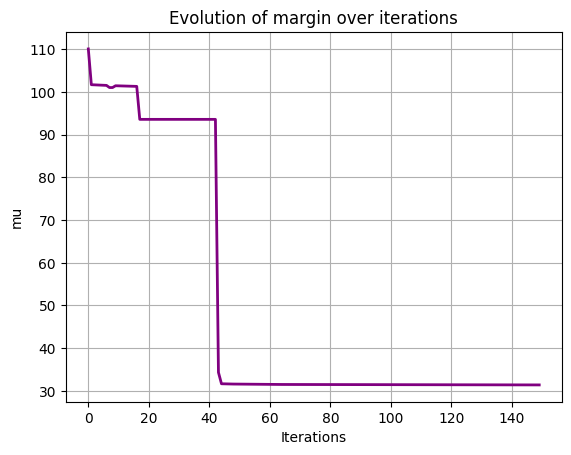

17:46:39 | INFO | machinemoo | Fit runtime: 2899.32 seconds


In [17]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names,
                            model_name = model_name,
                            gradient = True
                            )
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

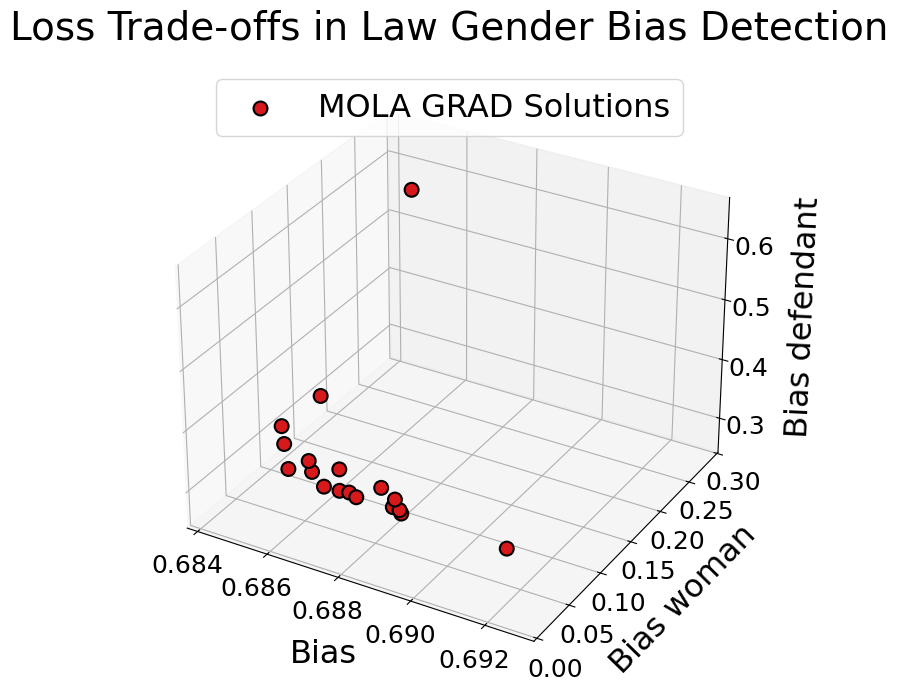

In [18]:
title="Loss Trade-offs in Law Gender Bias Detection"
plot_pareto(methods={'mola_grad': objs},
            labels=task_names, 
            title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/3_objs_mola_grad.pdf'
            )

### Random Weights

In [19]:
method = 'random_weight'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names,
                            model_name = model_name,
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

17:46:44 | WARNING | machinemoo | Ignored parameters for random_weights: {'targetGap', 'nodeGap', 'nodeTimeLimit'}
17:46:44 | DEBUG | machinemoo | Filtered parameters for random_weights: {'targetSize': 150, 'norm': False}
17:46:44 | DEBUG | machinemoo | Finding 1th individual minima
Epoch 1/2 - Training:   0%|          | 0/5 [00:00<?, ?it/s]/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/torch/utils/checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
Evaluating: 100%|██████████| 5/5 [00:05<00:00,  1.18s/it]
17:47:03 | DEBUG | machinemoo | Finding 2th individual minima
Evaluating: 100%|██████████| 5/5 [00:05<00:00,  1.17s/it]
17:47:22 | DEBUG | machinemoo | Finding 3th individual minima
Evaluating: 100%|██████████| 5/5 [00:05<00:00,  1.16s/it]
17:48:00 | DEBUG | machinemoo | 4th solution
Evaluating: 100%|██████████| 5/5 [00:05<00:00,  1.18s/it]
17:48:19 | DEBUG | machinemoo | 5th solution
Eval

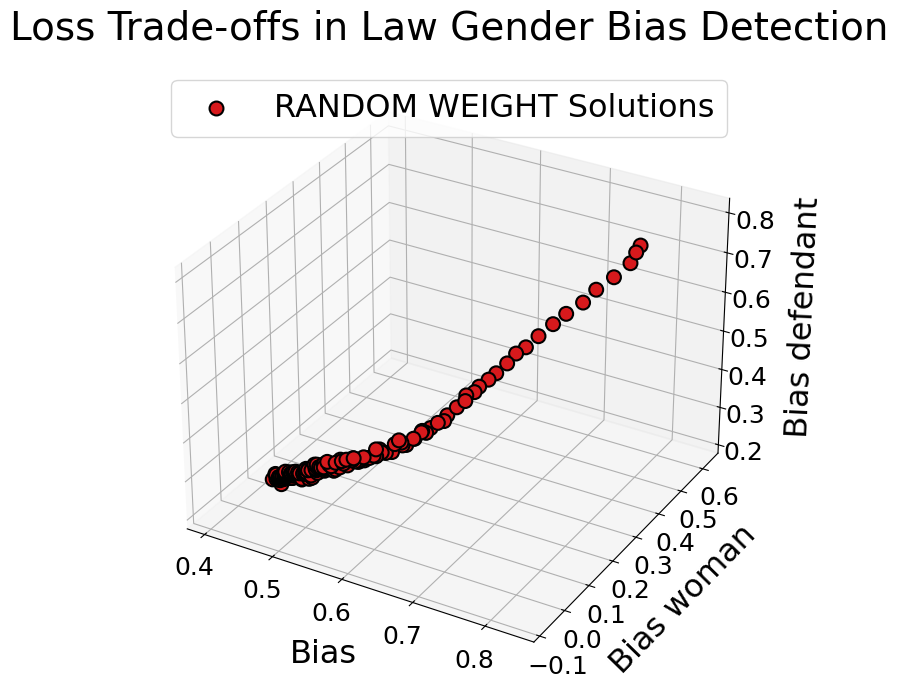

In [20]:
title="Loss Trade-offs in Law Gender Bias Detection"
plot_pareto(methods={'random_weight': objs},
            labels=task_names, 
            title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/3_objs_rw.pdf'
            )

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

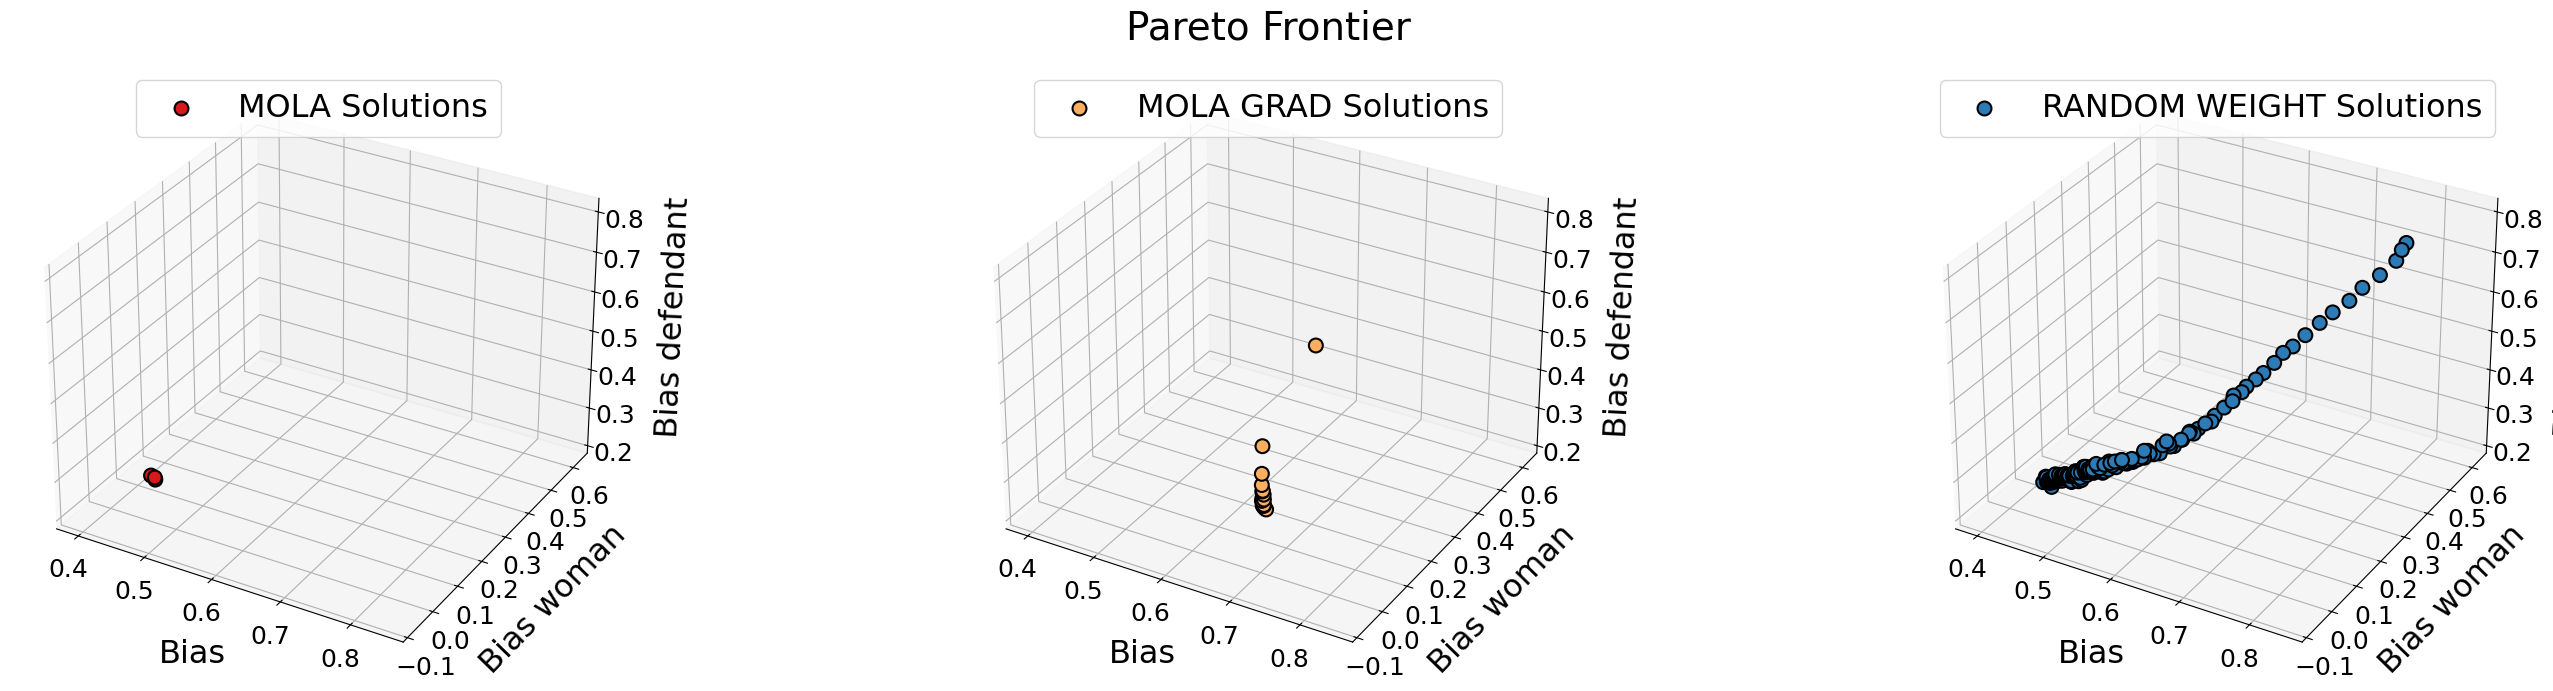

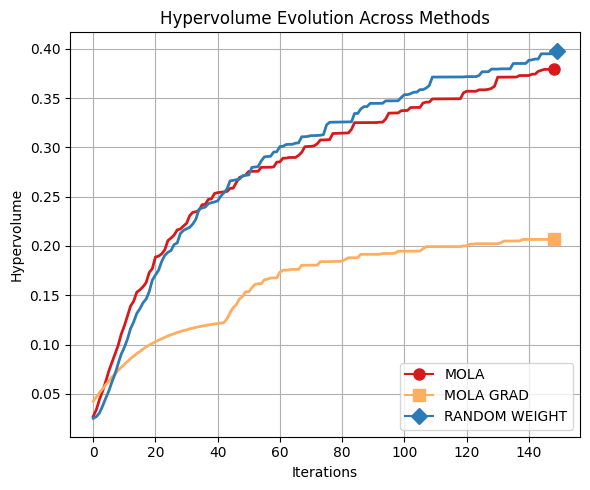

In [ ]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

plot_pareto(methods=pareto_dict,
            labels=task_names, 
            # title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/3_objs_methods.pdf'
            )
plot_multiple_hypervolumes(methods_hv=hypervolumes_dict)